In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F

In [2]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'cuda'

In [3]:
X = torch.linspace(-5, 5, 200).unsqueeze(1)
Y = X**2

In [4]:
print(X.shape)
print(Y.shape)

torch.Size([200, 1])
torch.Size([200, 1])


In [5]:
class StackNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.stack = nn.Sequential(
            nn.Linear(1, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        result = self.stack(x)
        return result

In [6]:
model = StackNet().to(device)
print(model)

StackNet(
  (stack): Sequential(
    (0): Linear(in_features=1, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)


In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
X = X.to(device)
Y = Y.to(device)

In [9]:
for epoch in range(400):
    y_pred = model(X)
    loss = criterion(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Loss: {loss.item():.4f}")

Loss: 10.3889
Loss: 5.3277
Loss: 2.6806
Loss: 1.4407


In [10]:
y_pred = model(X)

In [11]:
X_np = X.cpu().numpy()
Y_np = Y.cpu().numpy()
Y_pred_np = y_pred.detach().cpu().numpy()

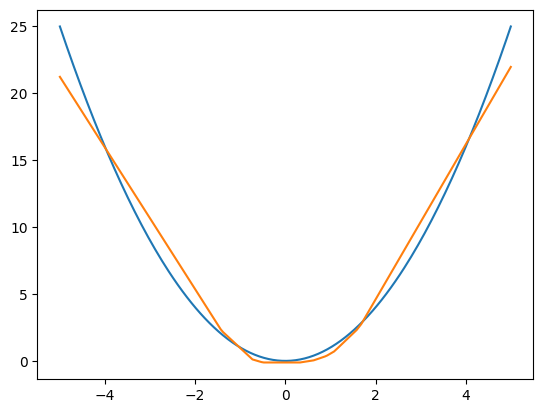

In [12]:
plt.plot(X_np, Y_np)
plt.plot(X_np, Y_pred_np)
plt.show()

In [13]:
class DesacopledNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(1, 10)
        self.output = nn.Linear(10, 1)

    def forward(self, x):
        h = F.relu(self.hidden(x))
        y = self.output(h)
        return y, h

In [14]:
model = DesacopledNet().to(device)
print(model)

DesacopledNet(
  (hidden): Linear(in_features=1, out_features=10, bias=True)
  (output): Linear(in_features=10, out_features=1, bias=True)
)


In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [16]:
for epoch in range(400):
    y_pred, h = model(X)
    loss = criterion(y_pred, Y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Loss: {loss.item():.4f}")

Loss: 9.2657
Loss: 5.0646
Loss: 2.6374
Loss: 1.4589


In [17]:
h.shape

torch.Size([200, 10])

In [18]:
y_pred, h = model(X)

In [19]:
type(h)

torch.Tensor

In [20]:
X_np = X.cpu().numpy()
Y_np = Y.cpu().numpy()
Y_pred_np = y_pred.detach().cpu().numpy()
h_np = h.detach().cpu().numpy()

In [21]:
h_np.shape

(200, 10)

In [22]:
h_np[:, 0].shape

(200,)

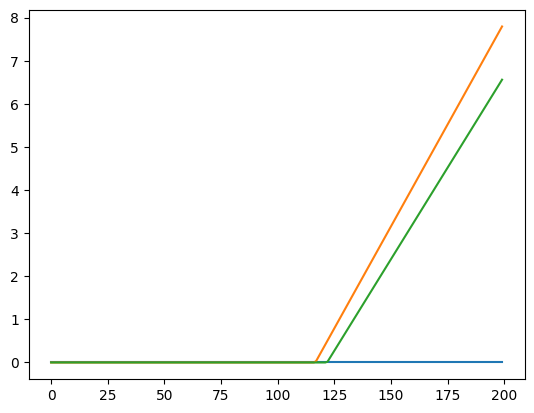

In [23]:
#plt.plot(X_np, Y_np)
#plt.plot(X_np, Y_pred_np)
for i in range(3):
    plt.plot(h_np[:,i])
plt.show()

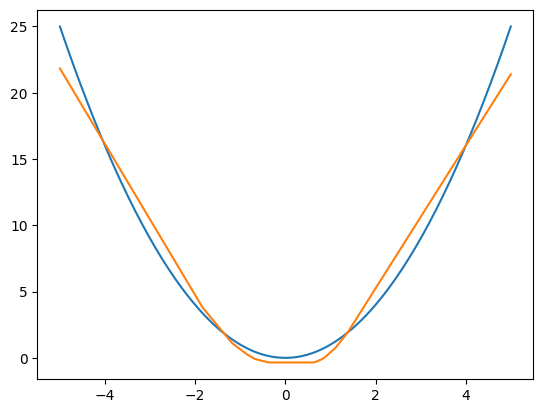

In [24]:
plt.plot(X_np, Y_np)
plt.plot(X_np, Y_pred_np)
plt.show()